# Comparative analysis of approaches to Reverse-Int problem in Python
Prepared by Viktar Nikanchyk

<center><h2>Problem description</h2></center>
The task is to implement a function which receives signed integer `x` as input and reverses
its decimal digits preserving its sign. Return value `y` is also a signed integer with the reversed order
of decimal digits compared to `x`.

**Examples:**
- If `x = 12345`, then `y = 54321`.
- If `x = -987`, then `y = -789`.
- If `x = 1200`, then `y = 21` (leading zeros after reversal are dropped).
- If `x = 0`, then `y = 0`.

**Implementation challenges:**
1.  **Handling of sign:** the minus sign must be preserved.
2.  **Treatment of trailing zeros:** zeros at the end of the original number become leading zeros in the reversed result and must be dropped.
3.  **Potential overflows:** 64-bit integer overflow should be considered when interacting with libraries in statically typed languages like C++.

**Business-challenges:**
1.  **Performance:** comparative analysis of different approaches' performance should be performed.
2.  **Use-cases analysis:** optimal approach should be chosen for each use-case depending on practical sense of input values and business priorities:
performance, readability or rapid prototyping.

<center><h2>Approaches analysis</h2></center>

### Arithmetic approach in Python
**Description:**
using division with remainder we can extract digits from `x` one by one and "rewrite" them in reversed order using multiplication:

In [2]:
def reverse_arithmetic(x: int) -> int:
    sign = -1 if x < 0 else 1 # sign handling
    x = abs(x)

    reversed_num = 0

    while x > 0:
        last_digit = x % 10
        reversed_num = reversed_num * 10 + last_digit
        x //= 10

    return sign * reversed_num

**Asymptotic complexity:**&emsp;`O(log x)`<br>
**Memory complexity:**&emsp;`O(log x)` (due to Python integer arbitrary size)

**Advantages:**
1.  Natural handling of postfix zeros using arithmetic operations.
2.  Intuitive simplicity and theoretical clearness.

**Disadvantages:**
1.  Python arithmetics overheads: each modulo (`%`) and division (`//`) operation creates a new integer object (new heap allocation). Immutability of Python objects and absence of strong compile-time optimizations result in slower performance compared to compiled languages with static typization.
2.  Imperative style: in Python ecosystem preference is given to more declarative approaches.

### String-based approach in Python
**Description:**
we can convert integer to string, reverse it using Python slicing and convert it back to integer:

In [3]:
def reverse_string(x: int) -> int:
    sign = -1 if x < 0 else 1 # sign handling
    reversed_str = str(abs(x))[::-1]
    return sign * int(reversed_str)

**Asymptotic complexity:**&emsp;`O(log x)`<br>
**Memory complexity:**&emsp;`O(log x)`

**Advantages:**
1.  Natural handling of postfix zeros using `int()` converter.
2.  Performance: the reversal (`[::-1]`) and conversion (`int()`) are implemented in C which allows to use advanced optimizations for the reversing
loops.
3.  Readability and declarative style.

**Disadvantages:**
1.  Memory overhead: approach requires to allocate additional memory for the reversed string copy which might become unwanted for giant integers.

### Arithmetic approach in C++ (Python as a glue)
**Description:**
we can overcome arithmetic approach disadvantages (imperative style, performance issues) by creating a custom library in C++.<br>
For maximal performance, the core logic is implemented in C++ (custom library `reverse_int.so`) and exposed to Python using `pybind11`:

```cpp
#include <pybind11/pybind11.h>

long long reverse_cpp(long long x) {
    long long sign = (x < 0) ? -1 : 1;
    x = (x < 0) ? -x : x;
    long long rev = 0;
    while (x > 0) {
        rev = rev * 10 + x % 10;
        x /= 10;
    }
    return sign * rev;
}

PYBIND11_MODULE(reverse_int, m) {
    m.def("reverse", &reverse_cpp, "Reverse integer");
}
```
<br>
This approach eliminates Python interpreter overhead and provides declarative interface:

In [ ]:
import reverse_int # custom library
print(reverse_int.reverse(-123)) # call demonstration

**Asymptotic complexity:**&emsp;`O(log x)`<br>
**Memory complexity:**&emsp;`O(1)`

**Advantages:**
1.  Maximal performance (C++ implementation).
2.  Declarative style and readability.

**Disadvantages:**
1.  Potential overflow issues: input integer `x` and the reversed result `y` must not have absolute values greater than 64-bit integer limit (`~9.22 × 10¹⁸`).
Though, this limit can be raised using 128-bit integer extensions in the C++ library implementation.

<center><h2>Performance analysis</h2></center>

To compare approaches' performance, average execution time over 10'000 runs is analyzed depending on input integer `x` decimal length:

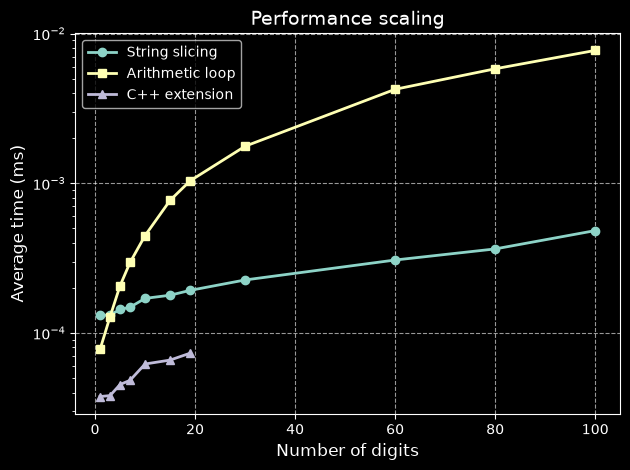

##### Average time over 10000 runs

|   Digits |   String |   Arithmetic | C++ (pybind11)   |
|---------:|---------:|-------------:|:-----------------|
|        1 | 0.000131 |     7.8e-05  | 0.000038         |
|        3 | 0.000132 |     0.000128 | 0.000038         |
|        5 | 0.000144 |     0.000207 | 0.000045         |
|        7 | 0.000149 |     0.000296 | 0.000048         |
|       10 | 0.00017  |     0.000447 | 0.000062         |
|       15 | 0.000179 |     0.000769 | 0.000066         |
|       19 | 0.000193 |     0.001037 | 0.000073         |
|       30 | 0.000226 |     0.001767 | —                |
|       60 | 0.000307 |     0.004243 | —                |
|       80 | 0.000364 |     0.005816 | —                |
|      100 | 0.000483 |     0.007715 | —                |

In [5]:
import timeit
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def generate_test_numbers(digits: int) -> int:
    """Generate number with required digits count"""
    return int('1' * digits)

def performance_benchmark(func, x: int, number=10000):
    """Performance benchmark function (average time over 10000 runs)"""
    timer = timeit.Timer(lambda: func(x))
    return timer.timeit(number=number) / number * 1000

performance_results = list()
digit_counts = [1, 3, 5, 7, 10, 15, 19, 30, 60, 80, 100] # analyzed input length values

for digits in digit_counts:
    x = generate_test_numbers(digits)

    time_str = performance_benchmark(reverse_string, x)
    time_arith = performance_benchmark(reverse_arithmetic, x)
     # overflow prevention for native C++ approach
    time_cpp = performance_benchmark(reverse_int.reverse, x) if x <= 2**63 - 1 else None

    performance_results.append({
        'Digits': digits,
        'String': time_str,
        'Arithmetic': time_arith,
        'C++ (pybind11)': time_cpp
    })

performance_df = pd.DataFrame(performance_results)

performance_df_formatted = performance_df.copy()
performance_df_formatted['String'] = performance_df_formatted['String'].map(lambda x: f'{x:.6f}')
performance_df_formatted['Arithmetic'] = performance_df_formatted['Arithmetic'].map(lambda x: f'{x:.6f}')
performance_df_formatted['C++ (pybind11)'] = performance_df_formatted['C++ (pybind11)'].map(
    lambda x: f'{x:.6f}' if pd.notna(x) else '—'
)

plt.figure(6)

plt.plot(performance_df['Digits'], performance_df['String'], marker='o', label='String slicing', linewidth=2)
plt.plot(performance_df['Digits'], performance_df['Arithmetic'], marker='s', label='Arithmetic loop', linewidth=2)
plt.plot(performance_df['Digits'], performance_df['C++ (pybind11)'], marker='^', label='C++ extension', linewidth=2)

plt.xlabel('Number of digits', fontsize=12)
plt.ylabel('Average time (ms)', fontsize=12)
plt.title('Performance scaling', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.yscale('log')
plt.tight_layout()
plt.show() # chart presentation

markdown_table = performance_df_formatted.to_markdown(index=False) # table presentation
display(Markdown(f"##### Average time over 10000 runs\n\n{markdown_table}"))

**Conclusion**: as expected, C++-native arithmetic approach significantly outperforms other methods, and string-based method is a faster choice
when using only Python standard tools.

<center><h2>Resources consumption analysis</h2></center>

To compare approaches' resources consumption, average memory consumption over 10'000 runs is analyzed
depending on input integer `x` decimal length:

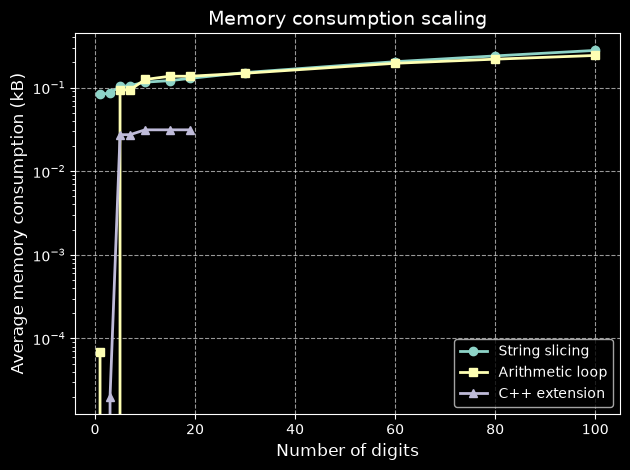

##### Average memory consumption over 10000 runs (kB)

|   Digits |   String |   Arithmetic | C++ (pybind11)   |
|---------:|---------:|-------------:|:-----------------|
|        1 | 0.083147 |     6.8e-05  | 0.000000         |
|        3 | 0.085951 |     0        | 0.000020         |
|        5 | 0.103516 |     0.09375  | 0.027344         |
|        7 | 0.105469 |     0.09375  | 0.027344         |
|       10 | 0.116211 |     0.125    | 0.031250         |
|       15 | 0.121094 |     0.136719 | 0.031250         |
|       19 | 0.128906 |     0.136719 | 0.031250         |
|       30 | 0.151367 |     0.148438 | —                |
|       60 | 0.204102 |     0.195312 | —                |
|       80 | 0.239258 |     0.218753 | —                |
|      100 | 0.27832  |     0.242296 | —                |

In [6]:
import tracemalloc

def memory_benchmark(func, x: int, number=10000):
    """Average memory consumption over 10000 runs"""
    peaks = list()

    for _ in range(number):
        tracemalloc.start()
        func(x)
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        peaks.append(peak / 1024)

    return sum(peaks) / len(peaks)

memory_results = list()
digit_counts = [1, 3, 5, 7, 10, 15, 19, 30, 60, 80, 100] # analyzed input length values

for digits in digit_counts:
    x = generate_test_numbers(digits)

    memory_str = memory_benchmark(reverse_string, x)
    memory_arith = memory_benchmark(reverse_arithmetic, x)
     # overflow prevention for native C++ approach
    memory_cpp = memory_benchmark(reverse_int.reverse, x) if x <= 2**63 - 1 else None

    memory_results.append({
        'Digits': digits,
        'String': memory_str,
        'Arithmetic': memory_arith,
        'C++ (pybind11)': memory_cpp
    })

memory_df = pd.DataFrame(memory_results)

memory_df_formatted = memory_df.copy()
memory_df_formatted['String'] = memory_df_formatted['String'].map(lambda x: f'{x:.6f}')
memory_df_formatted['Arithmetic'] = memory_df_formatted['Arithmetic'].map(lambda x: f'{x:.6f}')
memory_df_formatted['C++ (pybind11)'] = memory_df_formatted['C++ (pybind11)'].map(
    lambda x: f'{x:.6f}' if pd.notna(x) else '—'
)

plt.figure(6)

plt.plot(memory_df['Digits'], memory_df['String'], marker='o', label='String slicing', linewidth=2)
plt.plot(memory_df['Digits'], memory_df['Arithmetic'], marker='s', label='Arithmetic loop', linewidth=2)
plt.plot(memory_df['Digits'], memory_df['C++ (pybind11)'], marker='^', label='C++ extension', linewidth=2)

plt.xlabel('Number of digits', fontsize=12)
plt.ylabel('Average memory consumption (kB)', fontsize=12)
plt.title('Memory consumption scaling', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.yscale('log')
plt.tight_layout()
plt.show() # chart presentation

markdown_table = memory_df_formatted.to_markdown(index=False) # table presentation
display(Markdown(f"##### Average memory consumption over 10000 runs (kB)\n\n{markdown_table}"))

Arithmetic approach in Python and string-based approach don't differ much on tests with small number of digits (less than 100) because of objects creation overhead domination. But for giant numbers they both demonstrate visible linear growth (arithmetic approach requires additional memory to save reversed version of integer of arbitrary size), although arithmetic approach is more
economical (it stores integer as a sequence of bits which takes less place than the sequence of separate characters of the string):

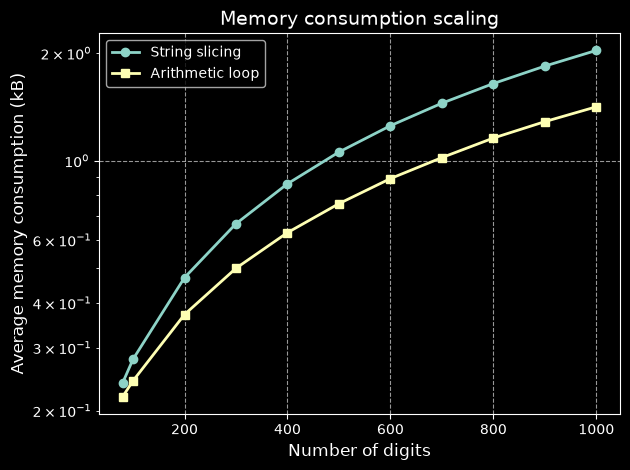

##### Average memory consumption over 10000 runs (kB)

|   Digits |   String |   Arithmetic |
|---------:|---------:|-------------:|
|       80 | 0.239324 |     0.21889  |
|      100 | 0.27832  |     0.242191 |
|      200 | 0.470703 |     0.37117  |
|      300 | 0.666016 |     0.500006 |
|      400 | 0.861328 |     0.628919 |
|      500 | 1.05664  |     0.757898 |
|      600 | 1.25195  |     0.890644 |
|      700 | 1.44727  |     1.01964  |
|      800 | 1.64258  |     1.15634  |
|      900 | 1.83789  |     1.2853   |
|     1000 | 2.0332   |     1.41417  |

In [7]:
memory_results = list()
digit_counts = [80, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000] # analyzed input length values (big tests)

for digits in digit_counts:
    x = generate_test_numbers(digits)

    memory_str = memory_benchmark(reverse_string, x)
    memory_arith = memory_benchmark(reverse_arithmetic, x)

    memory_results.append({
        'Digits': digits,
        'String': memory_str,
        'Arithmetic': memory_arith,
    })

memory_df = pd.DataFrame(memory_results)

memory_df_formatted = memory_df.copy()
memory_df_formatted['String'] = memory_df_formatted['String'].map(lambda x: f'{x:.6f}')
memory_df_formatted['Arithmetic'] = memory_df_formatted['Arithmetic'].map(lambda x: f'{x:.6f}')

plt.figure(6)

plt.plot(memory_df['Digits'], memory_df['String'], marker='o', label='String slicing', linewidth=2)
plt.plot(memory_df['Digits'], memory_df['Arithmetic'], marker='s', label='Arithmetic loop', linewidth=2)

plt.xlabel('Number of digits', fontsize=12)
plt.ylabel('Average memory consumption (kB)', fontsize=12)
plt.title('Memory consumption scaling', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.yscale('log')
plt.tight_layout()
plt.show() # chart presentation

markdown_table = memory_df_formatted.to_markdown(index=False) # table presentation
display(Markdown(f"##### Average memory consumption over 10000 runs (kB)\n\n{markdown_table}"))

**Conclusion:** C++-native approach is far more economical than other approaches because of stack allocations. String-based approach and
arithmetic approach in Python show linear dependence of memory consumption on the number of digits, although arithmetic approach is more economical
because of compact integer storage.

<center><h2>Use-cases analysis and conclusion</h2></center>

Considering analytical results, we can go through potential use-cases and propose optimal approaches for them:

- **High-load systems and performance-critical modules**: C++-native approach is strongly recommended due to its absolute performance superiority and
modest memory consumption. Integrating 128-bit integer extension into C++ library implementation, we can achieve upper limit of processed values
that is enough for the absolute majority of practical challenges (typical business applications).
- **Prototyping and scientific calculations**: for performance-insensitive cases (fast prototyping, scientific calculations) string-based approach in Python is recommended due to its readability and brevity.
- **Educational programming**: for educational purposes arithmetic approach in Python might be used to explain arithmetic sense of the algorithm
using lightweight Python syntax.

---
🔗 All materials and source code are available on GitHub:
[https://github.com/vittorio-niko/reverse_int_research](https://github.com/vittorio-niko/reverse_int_research)